# Exploratory Data Analysis (EDA) for the Weather Scraping Project

This notebook explores the processed weather dataset collected from **Open-Meteo**, **Weather Underground**, and **Time and Date**.

## Goals
- understand the structure and quality of the scraped data
- check missing values, duplicates, and suspicious values
- compare weather patterns across cities and sources
- extract useful insights for the final report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# Robust path: works whether the notebook is run from /eda or project root
candidate_paths = [
    Path("../data/processed/weather_data.csv"),
    Path("data/processed/weather_data.csv"),
]

data_path = None
for path in candidate_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find data/processed/weather_data.csv")

print("Using file:", data_path.resolve())

Using file: C:\Users\Lenovo\Desktop\WebScraping\data\processed\weather_data.csv


## 1. Load the dataset

In [2]:
df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (19480, 9)


,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition
0,TimeAndDate,Auckland,New Zealand,2026-02-28 00:00:00+00:00,27.0,18.0,100.0,11.0,NaN
1,TimeAndDate,Beirut,Lebanon,2026-02-28 00:00:00+00:00,24.0,18.0,96.0,11.0,NaN
2,TimeAndDate,Berlin,Germany,2026-02-28 00:00:00+00:00,16.0,18.0,100.0,11.0,NaN
3,TimeAndDate,Buenos Aires,Argentina,2026-02-28 00:00:00+00:00,32.0,18.0,100.0,11.0,NaN
4,TimeAndDate,Cairo,Egypt,2026-02-28 00:00:00+00:00,27.0,18.0,88.0,11.0,NaN


## 2. Basic overview

In [3]:
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nInfo:")
df.info()


Columns:
['SourceWebsite', 'City', 'Country', 'ScrapeDateTime', 'Temperature_C', 'FeelsLike_C', 'Humidity_%', 'WindSpeed_kmh', 'Condition']

Data types:
SourceWebsite         str
City                  str
Country               str
ScrapeDateTime        str
Temperature_C     float64
FeelsLike_C       float64
Humidity_%        float64
WindSpeed_kmh     float64
Condition             str
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 19480 entries, 0 to 19479
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SourceWebsite   19480 non-null  str    
 1   City            19480 non-null  str    
 2   Country         19480 non-null  str    
 3   ScrapeDateTime  19480 non-null  str    
 4   Temperature_C   19480 non-null  float64
 5   FeelsLike_C     18908 non-null  float64
 6   Humidity_%      18908 non-null  float64
 7   WindSpeed_kmh   19480 non-null  float64
 8   Condition       18172 non-null  str    

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SourceWebsite,19480,3,Open-Meteo,16786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,19480,26,Beirut,1060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,19480,27,United States,2241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScrapeDateTime,19480,2662,2026-03-29 00:00:00+00:00,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature_C,19480.0,NaN,NaN,NaN,16.983076,8.706554,-10.4,10.6,17.1,23.2,55.0
FeelsLike_C,18908.0,NaN,NaN,NaN,15.337873,9.830366,-18.7,8.0,16.6,21.8,55.0
Humidity_%,18908.0,NaN,NaN,NaN,70.787709,20.357333,6.0,57.0,74.0,88.0,100.0
WindSpeed_kmh,19480.0,NaN,NaN,NaN,10.11119,6.169635,0.0,5.5,9.4,13.0,43.8
Condition,18172,62,clear sky,5638,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Initial data quality checks

In [5]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
SourceWebsite        0
City                 0
Country              0
ScrapeDateTime       0
Temperature_C        0
FeelsLike_C        572
Humidity_%         572
WindSpeed_kmh        0
Condition         1308
dtype: int64

Duplicate rows: 0


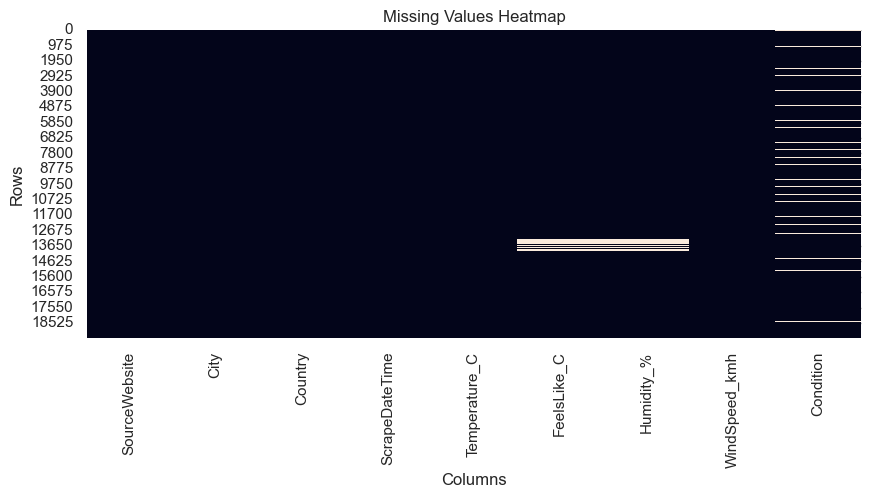

In [6]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## 4. Datetime cleaning and feature engineering

The original notebook converted `ScrapeDateTime`, but did not use it afterward.
Here we convert it properly and create extra time-based columns for analysis.

In [9]:
df.columns = df.columns.str.strip()

df["ScrapeDateTime"] = (
    df["ScrapeDateTime"]
    .astype(str)
    .str.strip()
    .replace({"": np.nan, "nan": np.nan})
)

df["ScrapeDateTime"] = pd.to_datetime(
    df["ScrapeDateTime"],
    errors="coerce",
    utc=True
)

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)
else:
    df["Date"] = df["ScrapeDateTime"].dt.date
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["ScrapeHour"] = df["ScrapeDateTime"].dt.hour
df["ScrapeDay"] = df["ScrapeDateTime"].dt.day_name()

print(df[["Date", "ScrapeDateTime", "ScrapeHour", "ScrapeDay"]].head())

                       Date            ScrapeDateTime  ScrapeHour ScrapeDay
0 2026-02-28 00:00:00+00:00 2026-02-28 00:00:00+00:00         0.0  Saturday
1 2026-02-28 00:00:00+00:00 2026-02-28 00:00:00+00:00         0.0  Saturday
2 2026-02-28 00:00:00+00:00 2026-02-28 00:00:00+00:00         0.0  Saturday
3 2026-02-28 00:00:00+00:00 2026-02-28 00:00:00+00:00         0.0  Saturday
4 2026-02-28 00:00:00+00:00 2026-02-28 00:00:00+00:00         0.0  Saturday


In [ ]:
print("Date range from Date column:")
print("Min:", df["Date"].min())
print("Max:", df["Date"].max())

print("\nDate range from ScrapeDateTime column:")
print("Min:", df["ScrapeDateTime"].min())
print("Max:", df["ScrapeDateTime"].max())

Date range from Date column:
Min: 2026-02-28 00:00:00
Max: 2026-04-08 00:00:00

Date range from ScrapeDateTime column:
Min: 2026-02-28 00:00:00+00:00
Max: 2026-04-08 00:24:33.248498+00:00


## 5. Categorical variables

In [ ]:
print("Unique cities:", df["City"].nunique())
print("Unique countries:", df["Country"].nunique())
print("Unique source websites:", df["SourceWebsite"].nunique())

print("\nSource counts:")
print(df["SourceWebsite"].value_counts())

print("\nTop weather conditions:")
print(df["Condition"].value_counts(dropna=False).head(15))

Unique cities: 26
Unique countries: 27
Unique source websites: 3

Source counts:
SourceWebsite
Open-Meteo            3055
WeatherUnderground    1698
TimeAndDate           1285
Name: count, dtype: int64

Top weather conditions:
Condition
Overcast             1147
Clear sky             739
NaN                   528
Partly Cloudy         476
Mainly clear          351
Cloudy                347
Light drizzle         340
Mostly Cloudy         306
Partly cloudy         240
Passing clouds.       150
Fair                  140
Clear.                113
Sunny.                 93
Scattered clouds.      74
Sunny                  66
Name: count, dtype: int64


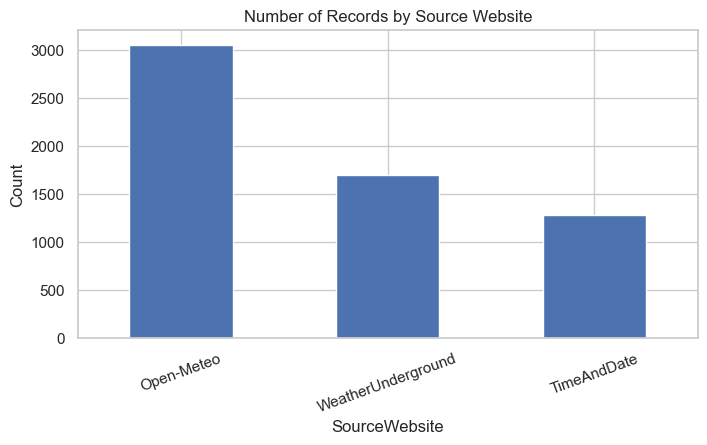

In [ ]:
plt.figure(figsize=(8, 4))
df["SourceWebsite"].value_counts().plot(kind="bar")
plt.title("Number of Records by Source Website")
plt.xlabel("SourceWebsite")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

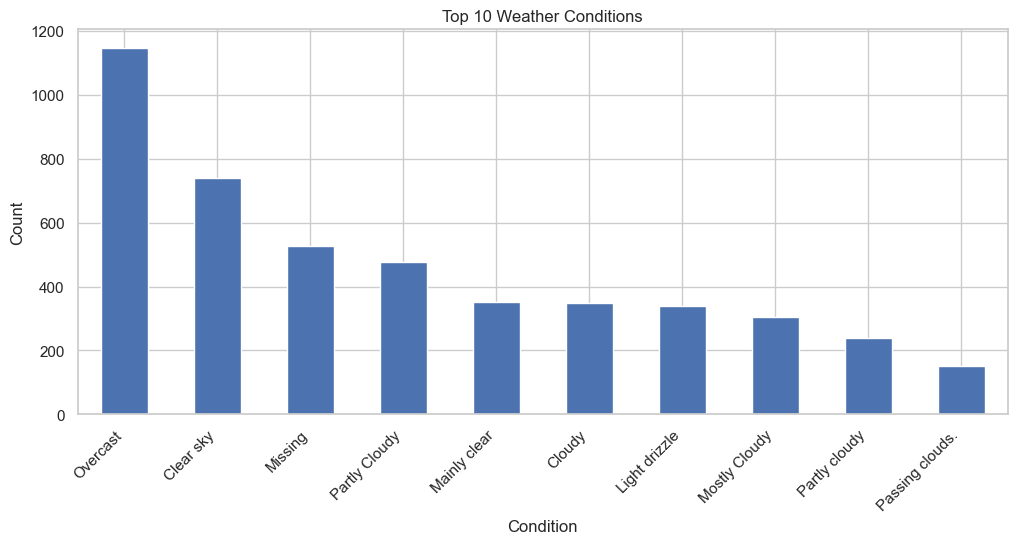

In [ ]:
plt.figure(figsize=(12, 5))
df["Condition"].fillna("Missing").value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Weather Conditions")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

## 6. Numerical variable distributions

In [ ]:
numeric_cols = ["Temperature_C", "FeelsLike_C", "Humidity_%", "WindSpeed_kmh"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature_C,6038.0,23.689117,14.490730,-1.5,14.40,20.00,27.22,60.0
FeelsLike_C,3933.0,17.201785,10.988522,-7.2,9.30,17.00,23.10,60.0
Humidity_%,5251.0,72.235955,19.256329,19.0,59.00,74.00,89.00,100.0
WindSpeed_kmh,5293.0,12.209123,7.169863,0.0,6.44,11.27,17.00,43.0


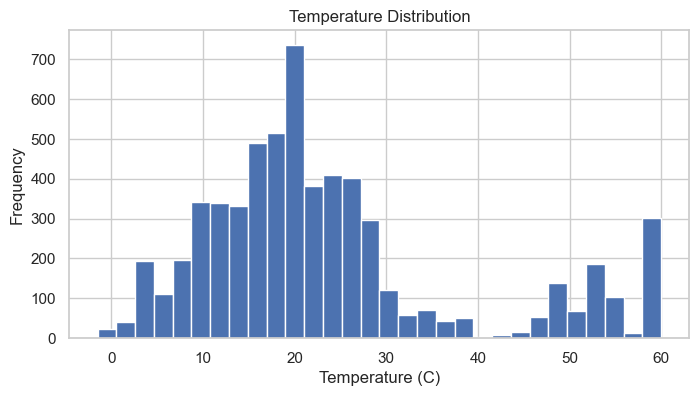

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df["Temperature_C"].dropna(), bins=30)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (C)")
plt.ylabel("Frequency")
plt.show()

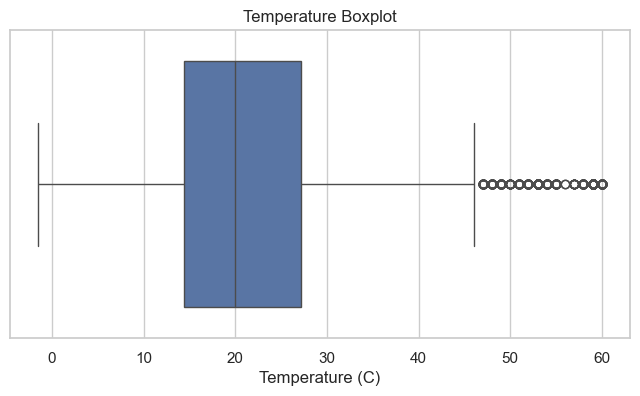

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Temperature_C"])
plt.title("Temperature Boxplot")
plt.xlabel("Temperature (C)")
plt.show()

## 7. Suspicious values / anomaly checks

This section is useful in scraping projects because strange values may come from:
- unit conversion issues
- parsing problems
- site structure changes
- missing or incorrectly scraped fields

In [ ]:
print("Rows with Temperature_C > 50:")
display(df[df["Temperature_C"] > 50].head(10))

print("Rows with Temperature_C < -20:")
display(df[df["Temperature_C"] < -20].head(10))

Rows with Temperature_C > 50:


,Date,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition,ScrapeHour,ScrapeDay
1872,2026-03-30,WeatherUnderground,Auckland,New Zealand,2026-03-30 12:21:55.723643+00:00,59.0,NaN,NaN,3.22,Partly Cloudy,12.0,Monday
1873,2026-03-30,WeatherUnderground,Auckland,New Zealand,2026-03-30 12:21:55.729388+00:00,51.0,NaN,NaN,14.48,Fair,12.0,Monday
1876,2026-03-30,WeatherUnderground,Auckland,New Zealand,2026-03-30 12:23:08.918954+00:00,59.0,NaN,NaN,3.22,Partly Cloudy,12.0,Monday
1878,2026-03-30,WeatherUnderground,Auckland,New Zealand,2026-03-30 12:24:21.810470+00:00,59.0,NaN,NaN,3.22,Partly Cloudy,12.0,Monday
1883,2026-03-30,WeatherUnderground,Auckland,New Zealand,2026-03-30 12:29:02.891573+00:00,59.0,NaN,NaN,3.22,Partly Cloudy,12.0,Monday
1888,2026-03-30,WeatherUnderground,Beirut,Lebanon,2026-03-30 12:19:19.156309+00:00,59.0,NaN,NaN,20.92,Showers Early,12.0,Monday
1890,2026-03-30,WeatherUnderground,Beirut,Lebanon,2026-03-30 12:19:39.792927+00:00,59.0,NaN,NaN,20.92,Showers Early,12.0,Monday
1893,2026-03-30,WeatherUnderground,Beirut,Lebanon,2026-03-30 12:22:00.037199+00:00,59.0,NaN,NaN,3.22,Partly Cloudy,12.0,Monday
1897,2026-03-30,WeatherUnderground,Beirut,Lebanon,2026-03-30 12:24:24.668515+00:00,59.0,NaN,NaN,19.31,Showers Early,12.0,Monday
1898,2026-03-30,WeatherUnderground,Beirut,Lebanon,2026-03-30 12:24:24.671077+00:00,59.0,NaN,NaN,3.22,Partly Cloudy,12.0,Monday


Rows with Temperature_C < -20:


,Date,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition,ScrapeHour,ScrapeDay


In [ ]:
print("Rows with Humidity_% outside 0-100:")
display(df[(df["Humidity_%"] < 0) | (df["Humidity_%"] > 100)])

print("Rows with negative wind speed:")
display(df[df["WindSpeed_kmh"] < 0])

Rows with Humidity_% outside 0-100:


,Date,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition,ScrapeHour,ScrapeDay


Rows with negative wind speed:


,Date,SourceWebsite,City,Country,ScrapeDateTime,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh,Condition,ScrapeHour,ScrapeDay


### Important note

If one source has much higher temperatures than the others, that may indicate a **unit mismatch**
(for example Fahrenheit values being stored as Celsius).

In [ ]:
source_temp_summary = df.groupby("SourceWebsite")["Temperature_C"].agg(["count", "mean", "median", "min", "max"]).sort_values("mean")
source_temp_summary

,count,mean,median,min,max
SourceWebsite,,,,,
Open-Meteo,3055,16.194730,16.6,-1.50,32.7
TimeAndDate,1285,20.592218,21.0,0.00,36.0
WeatherUnderground,1698,39.516482,47.0,16.11,60.0


## 8. City-level analysis

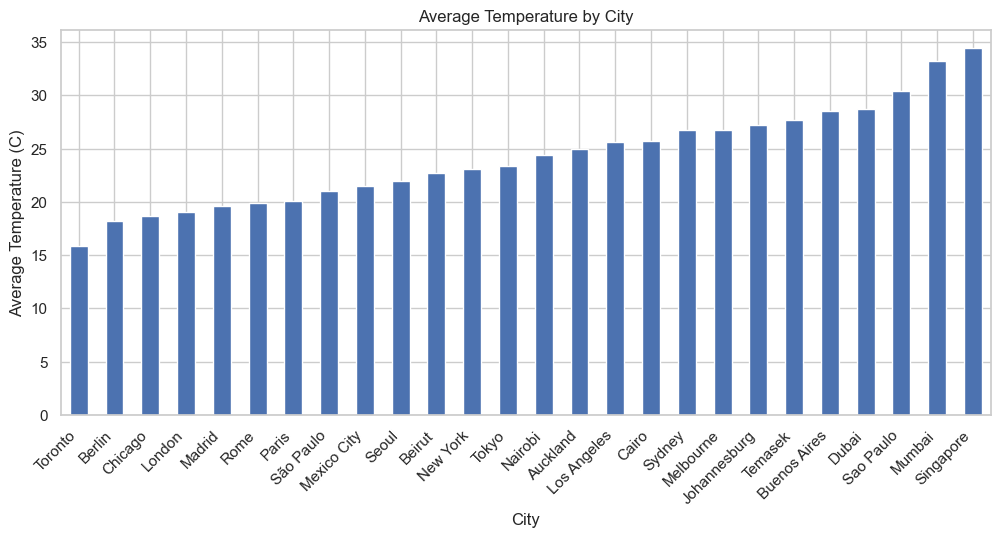

City
Toronto         15.837583
Berlin          18.167553
Chicago         18.710616
London          19.054615
Madrid          19.652616
Rome            19.858935
Paris           20.117747
São Paulo       20.998165
Mexico City     21.487299
Seoul           21.916638
Beirut          22.690664
New York        23.086549
Tokyo           23.393940
Nairobi         24.433063
Auckland        24.931376
Los Angeles     25.608466
Cairo           25.701740
Sydney          26.735891
Melbourne       26.780896
Johannesburg    27.175490
Temasek         27.641441
Buenos Aires    28.502273
Dubai           28.671980
Sao Paulo       30.419481
Mumbai          33.268071
Singapore       34.436819
Name: Temperature_C, dtype: float64

In [ ]:
city_temp = (
    df.groupby("City")["Temperature_C"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 5))
city_temp.plot(kind="bar")
plt.title("Average Temperature by City")
plt.xlabel("City")
plt.ylabel("Average Temperature (C)")
plt.xticks(rotation=45, ha="right")
plt.show()

city_temp

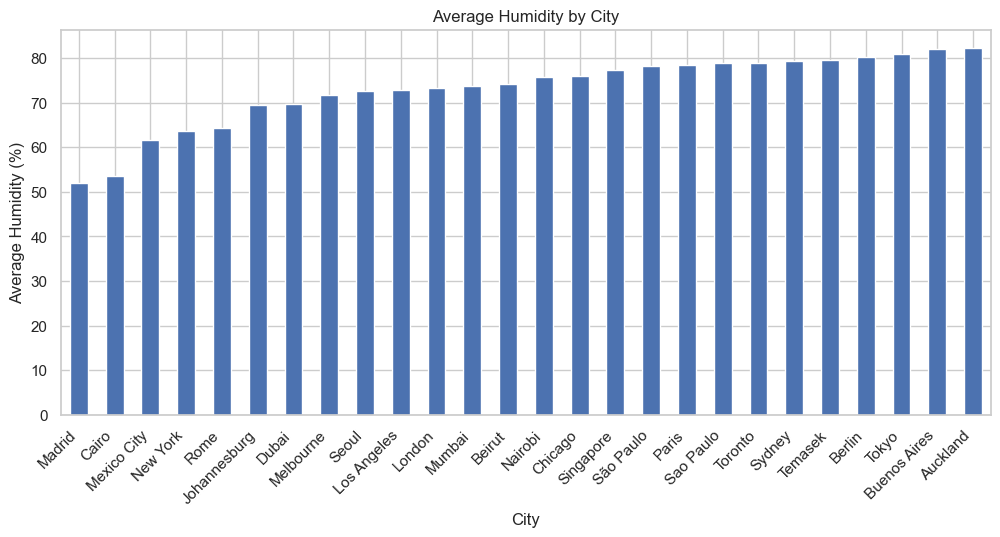

In [ ]:
city_humidity = (
    df.groupby("City")["Humidity_%"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 5))
city_humidity.plot(kind="bar")
plt.title("Average Humidity by City")
plt.xlabel("City")
plt.ylabel("Average Humidity (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## 9. Source comparison

In [ ]:
source_summary = df.groupby("SourceWebsite")[numeric_cols].mean().round(2)
source_summary

,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh
SourceWebsite,,,,
Open-Meteo,16.19,15.36,70.59,10.32
TimeAndDate,20.59,16.37,82.43,13.43
WeatherUnderground,39.52,35.33,67.03,15.22


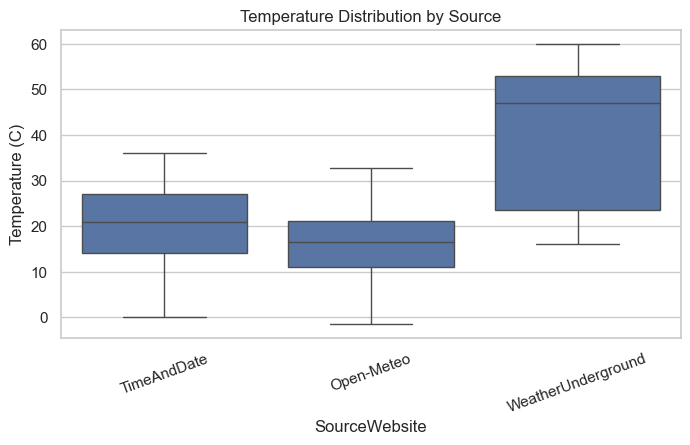

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="SourceWebsite", y="Temperature_C")
plt.title("Temperature Distribution by Source")
plt.xlabel("SourceWebsite")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=20)
plt.show()

This is one of the most important sections in your project, because the project is based on comparing
multiple scraped sources, not just describing one dataset.

## 10. Relationships between numerical features

In [ ]:
corr = df[numeric_cols].corr(numeric_only=True)
corr

,Temperature_C,FeelsLike_C,Humidity_%,WindSpeed_kmh
Temperature_C,1.000000,0.971523,-0.129696,0.084635
FeelsLike_C,0.971523,1.000000,-0.168928,-0.022789
Humidity_%,-0.129696,-0.168928,1.000000,-0.250135
WindSpeed_kmh,0.084635,-0.022789,-0.250135,1.000000


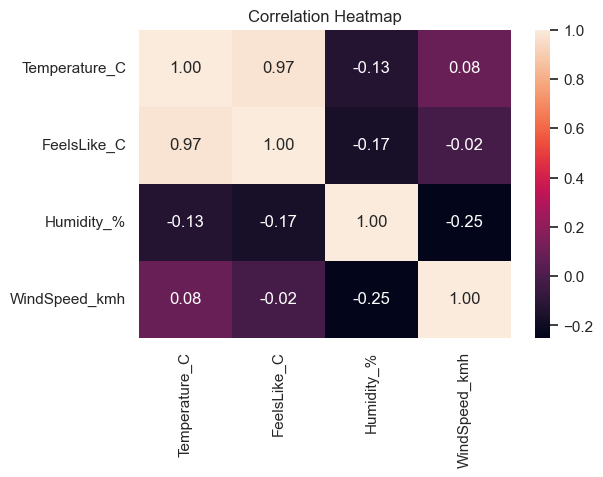

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

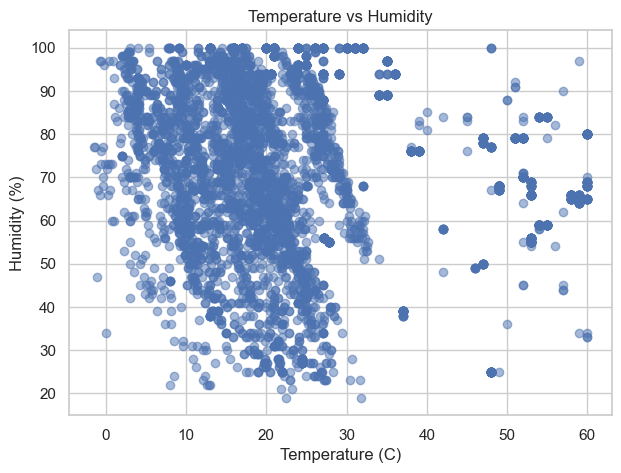

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Temperature_C"], df["Humidity_%"], alpha=0.5)
plt.xlabel("Temperature (C)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity")
plt.show()

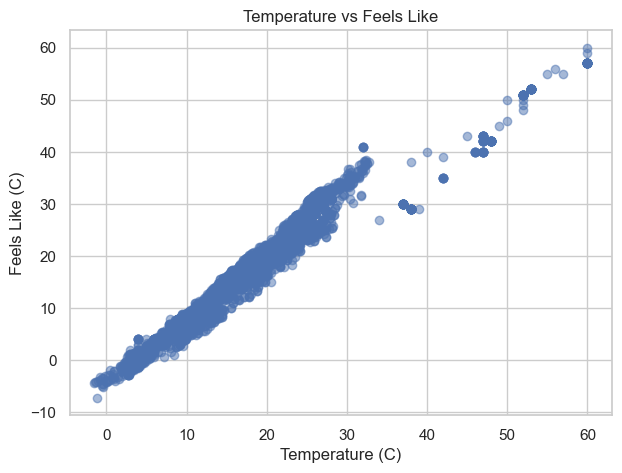

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Temperature_C"], df["FeelsLike_C"], alpha=0.5)
plt.xlabel("Temperature (C)")
plt.ylabel("Feels Like (C)")
plt.title("Temperature vs Feels Like")
plt.show()

## 11. Time-based analysis

In [ ]:
time_df = df.dropna(subset=["ScrapeDateTime"]).sort_values("ScrapeDateTime").copy()

print("Rows with valid ScrapeDateTime:", len(time_df))
time_df[["ScrapeDateTime", "Temperature_C", "SourceWebsite", "City"]].head()

Rows with valid ScrapeDateTime: 4912


,ScrapeDateTime,Temperature_C,SourceWebsite,City
0,2026-02-28 00:00:00+00:00,27.0,TimeAndDate,Auckland
23,2026-02-28 00:00:00+00:00,13.0,TimeAndDate,Toronto
22,2026-02-28 00:00:00+00:00,21.0,TimeAndDate,Tokyo
21,2026-02-28 00:00:00+00:00,30.0,TimeAndDate,Sydney
20,2026-02-28 00:00:00+00:00,34.0,TimeAndDate,Singapore


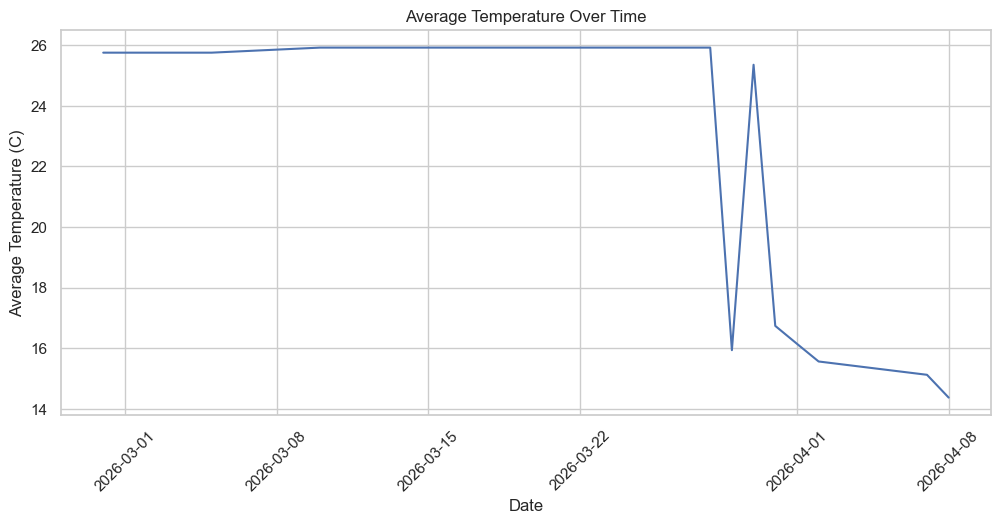

In [ ]:
daily_temp = (
    time_df.groupby(time_df["ScrapeDateTime"].dt.date)["Temperature_C"]
    .mean()
)

plt.figure(figsize=(12, 5))
daily_temp.plot()
plt.title("Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Average Temperature (C)")
plt.xticks(rotation=45)
plt.show()

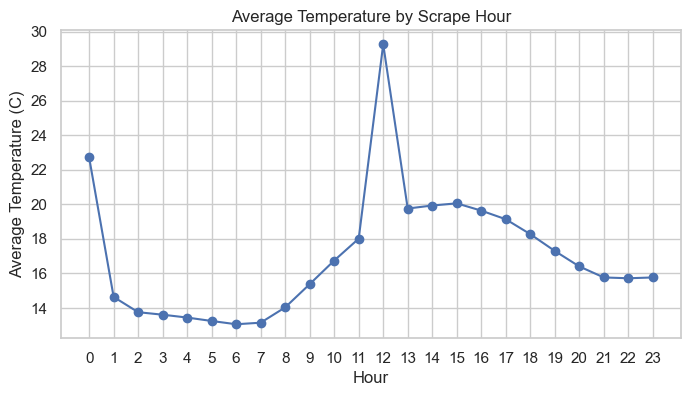

In [ ]:
hourly_temp = time_df.groupby("ScrapeHour")["Temperature_C"].mean()

plt.figure(figsize=(8, 4))
hourly_temp.plot(marker="o")
plt.title("Average Temperature by Scrape Hour")
plt.xlabel("Hour")
plt.ylabel("Average Temperature (C)")
plt.xticks(range(0, 24))
plt.show()